## 1. Importing libraries

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, skew
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append("../scripts")
from outlier_utils import print_outliers

## 2. Data Loading 

In [3]:
df = pd.read_csv("../data/Tanzania.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


## 3. Adding column & Date Parsing

In [4]:
# Add country column
df["Country"] = "Tanzania"

# Convert YEAR + DOY to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract month
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


- The dataset encodes dates using Year and Day-of-Year (DOY), which was converted into a proper datetime format to enable time-series analysis and seasonal interpretations.

## 4. Summary Statistics & Missing Values

In [5]:
# Replace sentinel values
df.replace(-999, np.nan, inplace=True)

# Duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 0


- No duplicates were found in any of the columns, which means every entry is unique

In [6]:
# Summary statistics
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


### Brief interpretation of the statistics

### **Dataset Overview**
- **Time period:** 2015 – 2026 (inclusive based on min/max YEAR)
- **Total daily records:** 4,108 (count is consistent for all columns)
- **Day-of-year range:** 1 to 366 (accounts for leap years)

---

### **Temperature (°C)**

| Variable | Mean | Min | Max | Interpretation |
|----------|------|-----|-----|----------------|
| **T2M** (mean daily temp) | 26.8 | 22.7 | 30.0 | Warm tropical / subtropical climate, small seasonal variation |
| **T2M_MAX** | 29.2 | 25.4 | 33.9 | Hot days possible; max ~34°C |
| **T2M_MIN** | 25.0 | 20.0 | 28.0 | Nights stay warm; min never below 20°C |
| **T2M_RANGE** | 4.13 | 0.94 | 7.59 | Diurnal range modest (~4°C typical) |

> *25th–75th percentile spread* is narrow (~2–3°C), indicating low interannual variability.

---

### **Precipitation & Humidity**

| Variable | Mean | Min | Max | Notes |
|----------|------|-----|-----|-------|
| **PRECTOTCORR** (mm/day) | 3.74 | 0.0 | 122.65 | Highly skewed: median = 0.64 → most days dry; extreme rain events up to ~123 mm/day |
| **RH2M** (%) | 77.1 | 60.1 | 91.1 | Consistently humid (75th %ile = 81%) |
| **QV2M** (g/kg) | 16.9 | 11.4 | 21.5 | High specific humidity → moist air mass |

> Precipitation distribution:  
> - 50% of days have ≤0.64 mm  
> - 75% of days have ≤3.79 mm → heavy rain is rare but extreme when it occurs (max = 122.7 mm)

---

### **Wind & Pressure**

| Variable | Mean | Min | Max | Interpretation |
|----------|------|-----|-----|----------------|
| **WS2M** (m/s) | 4.11 | 1.12 | 8.40 | Light to moderate mean wind |
| **WS2M_MAX** (m/s) | 5.19 | 1.55 | 11.74 | Gusts occasionally >10 m/s |
| **PS** (kPa) | 100.80 | 100.15 | 101.51 | Very stable surface pressure; narrow range |

> Pressure standard deviation = 0.28 kPa → minimal synoptic variation (typical of low-latitude or coastal stability).


---

### **Summary**
> *This dataset contains daily meteorological observations from 2015 to 2026. The climate is warm and humid (mean T2M ~27°C, RH2M ~77%) with a small diurnal temperature range (~4°C). Most days are dry (median precipitation = 0.64 mm/day), but extreme rainfall events exceed 120 mm/day. Wind speeds are light to moderate, and surface pressure is very stable.*


## 5. Missing values

In [7]:
# Missing values
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


- there are no null values, which makes our data interpretations and insights we draw from it more accurate since we dont miss anything

## 6. Outlier Detection

In [8]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

# Calculate z-scores
z_scores = np.abs(zscore(df[cols], nan_policy='omit'))

# Create named DataFrame for easier access
zscore_df = pd.DataFrame(
    z_scores, 
    columns=cols, 
    index=df.index
)

# FLAG the outliers (create a new column)
df['is_outlier'] = (zscore_df > 3).any(axis=1)  # ← THIS IS THE FLAG

# Report the counts
outliers = (z_scores > 3)
outlier_rows = df['is_outlier'].sum()
print("Outlier rows:", outlier_rows)
print(f"Percentage: {df['is_outlier'].mean()*100:.2f}%")

Outlier rows: 97
Percentage: 2.36%


- We have 97 rows with outlier values at one or more column, so now we check if they are erroneous values or seasonal extremities to make a decision whether to keep them or remove them.

### Check outliers by column

In [9]:
# 2. Check outliers by column
print_outliers(zscore_df, cols)

T2M: 1 outliers
T2M_MAX: 2 outliers
T2M_MIN: 4 outliers
PRECTOTCORR: 81 outliers
RH2M: 2 outliers
WS2M: 8 outliers
WS2M_MAX: 4 outliers


### Evaluating outliers

In [9]:
# 1. Physical possibility checks
impossible = df[
    (df["T2M_MAX"] < df["T2M_MIN"]) |  # Max < Min
    (df["RH2M"] > 100) |                # RH > 100%
    (df["RH2M"] < 0) |                  # RH < 0%
    (df["PRECTOTCORR"] < 0)             # Negative rain
]
print(f"Physically impossible rows: {len(impossible)}")

Physically impossible rows: 0


- We have no physically impossible rows, all values are within plausible ranges.

In [10]:
# 2. Check if outliers are seasonal
rain_outliers = df[zscore_df["PRECTOTCORR"] > 3] 
print("Precipitation outliers by month:")
print(rain_outliers["Month"].value_counts().sort_index())

Precipitation outliers by month:
Month
1      6
2      3
3     13
4     25
5     15
6      1
10     5
11    10
12     3
Name: count, dtype: int64


**Decision**: We will **keep** the precipitation outliers.

Precipitation extremes are physically real, meteorologically important for Tanzania, and critical for understanding flood risk, agricultural planning, and climate variability. Removing them would misrepresent the climate.

**Precipitation Outlier Distribution**

Outliers are distributed unevenly across months, with a strong peak in the **long rainy season** (March–May) and a secondary peak in the **short rainy season** (November–December).

- **March**: 13 outliers
- **April**: 25 outliers (highest)
- **May**: 15 outliers
- **November**: 10 outliers
- **December**: 3 outliers
- **January–February and October**: small numbers (1–6 each)
- **June**: only 1 outlier (dry season)

**Direction of outliers**: All precipitation outliers are **extreme high values** (heavy rainfall events), not dry outliers, because precipitation data is bounded at zero and skewed positive.

**Reasons for Keeping Extreme Rainfall Outliers in Tanzania**

**Tanzania’s bimodal rainfall pattern**
- The long rainy season (Masika) occurs March–May, with April typically the wettest month. This matches the outlier peak (April = 25 outliers).
- The short rainy season (Vuli) occurs October–December, with November peak (10 outliers) matching the secondary outlier cluster.

**Convective storms and topographic enhancement**
- Intense thunderstorms, often associated with the Intertropical Convergence Zone (ITCZ), produce very high daily rainfall totals.
- Lake Victoria, mountainous regions (Kilimanjaro, Meru, Eastern Arc Mountains), and the coast amplify rainfall through orographic lift and lake-effect convection.

**Climate variability modes**
- Indian Ocean Dipole (IOD) positive phases and El Niño events substantially increase extreme rainfall probability in Tanzania, especially during the short rains (October–December).
- Removing outliers would erase signals of these important climate drivers.

**Real-world impact relevance**
- Extreme daily rainfall drives flooding, landslides, infrastructure damage, and agricultural losses.
- For a climate report, capturing these extremes is essential for risk assessment, not a data error to clean.


In [11]:
min_temp_outliers = df[zscore_df["T2M_MIN"] > 3]
print("Minimun temprature outliers by month:")
print(min_temp_outliers["Month"].value_counts().sort_index())

temp_outliers = df[zscore_df["T2M"] > 3]
print("Temprature outliers by month:")
print(temp_outliers["Month"].value_counts().sort_index())

max_temp_outliers = df[zscore_df["T2M_MAX"] > 3]
print("Maximum Temprature outliers by month:")
print(temp_outliers["Month"].value_counts().sort_index())

Minimun temprature outliers by month:
Month
6    1
7    3
Name: count, dtype: int64
Temprature outliers by month:
Month
7    1
Name: count, dtype: int64
Maximum Temprature outliers by month:
Month
7    1
Name: count, dtype: int64


**Decision**: We will **keep** the temperature outliers.

Temperature extremes—both cold and hot—are physically real in Tanzania's diverse topography and carry important implications for agriculture, health, and energy demand. Removing them would obscure meaningful climate variability.

**Minimum Temperature Outliers**

**Distribution**: Only 4 outliers total across two months
- **June**: 1 outlier
- **July**: 3 outliers

**Direction**: Based on Tanzania's climate, these are **below normal** (unusually cold nights). Minimum temperature outliers in June–July represent exceptional nighttime cooling during the cool dry season.

**Reasons**:

**Tanzania's cool dry season (June–August)** – These months already have the lowest minimum temperatures of the year, especially in the southern highlands (Mbeya, Iringa, Njombe) and northern highlands (Arusha, Kilimanjaro region). Outliers in this season indicate even more pronounced nighttime cooling.

**Clear sky radiative cooling** – The dry season has minimal cloud cover, allowing heat absorbed during the day to escape rapidly at night. On outlier nights, this effect is maximized.

**Elevation effects** – Tanzania's highland areas experience much colder nights than coastal or lowland areas. Outlier cold nights likely originate from these highland stations.

**July peak** – July is typically the coldest month in Tanzania (many locations record their annual minimum temperature in July). Having 3 of the 4 outliers in July is climatologically consistent.

**Dry air intrusion** – Occasionally, very dry continental air masses (from southern Africa or the Indian Ocean during strong southeast trade winds) lower nighttime humidity further, enhancing radiative cooling.

---

**Temperature Outliers (Mean Daily Temperature)**

**Distribution**: Only 1 outlier total
- **July**: 1 outlier

**Direction**: This single outlier is likely a **below normal** (cold day). Mean daily temperature outliers are rare in Tanzania because daily means smooth out diurnal extremes.

**Reasons**:

The single mean temperature outlier in July almost certainly coincides with the minimum temperature outlier cluster. An exceptionally cold night, combined with a cooler-than-usual daytime maximum, produces an anomalous daily mean.

July's position at the core of the cool dry season makes it the only plausible month for such an event. Coastal bias in temperature data (warmer, less variable) would rarely produce mean temperature outliers, so this likely comes from a highland station.

---

**Maximum Temperature Outliers**

**Distribution**: Only 1 outlier total
- **July**: 1 outlier

**Direction**: Counterintuitively, a maximum temperature outlier in July would be **above normal** (unusually hot day), not cold. During the cool dry season, hot days are the anomaly.

**Reasons**:

**July hot days are rare but possible** – While July is Tanzania's coolest month, hot spells can occur when cloud cover dissipates completely and solar insolation is intense (southern hemisphere winter sun at low angles can still be strong at equatorial latitudes).

**Foehn/warming effects** – Downslope winds on the leeward side of mountains can cause sudden daytime warming even in July.

**This outlier likely does NOT coincide with the cold outliers** – The July maximum temperature outlier represents a different phenomenon: an unusually hot day within the coolest month. This is climatologically interesting rather than erroneous—it suggests intraseasonal variability where a single hot day can be statistically extreme against a background of consistently mild July temperatures.

**Low sample size caution** – With only one observation, this could also be a sensor anomaly on a specific day. Cross-check with nearby stations or reanalysis data (ERA5, CHIRTS) for that specific date if the report requires high confidence.

In [12]:
relative_humidity_outliers = df[zscore_df["RH2M"] > 3]
print("Relative humidity outliers by month:")
print(relative_humidity_outliers["Month"].value_counts().sort_index())

Relative humidity outliers by month:
Month
3    1
7    1
Name: count, dtype: int64


**Decision**: We will **keep** the relative humidity outliers.

Relative humidity extremes in Tanzania are physically meaningful, reflecting real atmospheric moisture variability driven by seasonal transitions, air mass changes, and localized topographic effects. With only two outliers total, removing them would have negligible statistical impact but removing them sets a questionable precedent for dismissing real events.

---

**Distribution**: Only 2 outliers total across two months
- **March**: 1 outlier
- **July**: 1 outlier

**Direction**: These outliers likely point in **opposite directions** due to Tanzania's seasonal climatology:
- **March outlier** – Likely **above normal** (unusually humid)
- **July outlier** – Likely **below normal** (unusually dry)

---

**Reasons for March Outlier (Above Normal Humidity)**

**End of the long rainy season (Masika)** – March is the onset of the long rainy season (March–May). Humidity is already elevated, but an outlier event represents exceptionally moist conditions.

**Active ITCZ overhead** – The Intertropical Convergence Zone (ITCZ) moves southward over Tanzania during March–April, bringing deep moisture, widespread cloud cover, and sustained rainfall. An outlier in March likely coincides with a period of particularly vigorous ITCZ activity.

**Saturated post-rainfall conditions** – After a heavy rain event, soils are wet, standing water is present, and evaporation keeps near-surface humidity near saturation (90–100%) for extended periods.

**Lake Victoria influence** – For stations near Lake Victoria, the lake's large surface area provides continuous moisture. An extreme humidity event here could exceed 95% RH with light winds.

**Low-level moisture convergence** – Strong convergence of moist air from the Indian Ocean and Congo Basin can push humidity values to climatological extremes in March.

---

**Reasons for July Outlier (Below Normal Humidity)**

**Core of the cool dry season** – July is Tanzania's driest and coolest month. Baseline RH is already low. An outlier represents exceptionally dry air.

**Strong southeast trade winds** – July has the strongest and most persistent southeast trade winds, which bring continental air from southern Africa. This air mass is cool, stable, and very dry after crossing long distances over land.

**Subsidence and atmospheric stability** – The subtropical high pressure system over southern Africa extends influence into Tanzania in July, suppressing convection and creating sinking, drying air.

**No moisture sources** – Unlike March, July has minimal convection, lake evaporation is reduced (cooler water temperatures), and the ITCZ is far north over Sudan and Ethiopia. Any humidity outlier would be a dryness extreme.

**Potential for very low RH (30–40%)** – In highland areas July RH can occasionally drop below 40%, which is remarkable for a tropical country. A single July outlier likely captures one of these exceptionally dry days.

In [13]:
mean_daily_wind_speed_outliers = df[zscore_df["WS2M"] > 3]
print("Mean daily wind speed outliers outliers by month:")
print(mean_daily_wind_speed_outliers["Month"].value_counts().sort_index())

max_daily_wind_speed_outliers = df[zscore_df["WS2M_MAX"] > 3]
print("Max daily wind speed outliers outliers by month:")
print(max_daily_wind_speed_outliers["Month"].value_counts().sort_index())

Mean daily wind speed outliers outliers by month:
Month
5     1
8     2
9     3
10    2
Name: count, dtype: int64
Max daily wind speed outliers outliers by month:
Month
5     1
7     1
10    2
Name: count, dtype: int64


**Decision**: We will **keep** the wind speed outliers.

Wind extremes in Tanzania are physically real, tied to identifiable seasonal wind systems, topography, and weather phenomena. Removing them would erase important signals for renewable energy (wind power), erosion risk, lake transport safety, and agricultural stress (evapotranspiration).

---

**Mean Daily Wind Speed Outliers**

**Distribution**: 8 outliers total across four months
- **May**: 1 outlier
- **August**: 2 outliers
- **September**: 3 outliers (highest)
- **October**: 2 outliers

**Direction**: All are **above normal** (unusually strong mean wind speeds). Weak wind outliers (calm conditions) are not represented here because calm days are common and not statistically extreme in this dataset.

**Reasons**:

**Southeast trade wind intensification (Kusi season)** – Tanzania's strongest and most persistent winds occur during May–October, peering from August through October. The southeast trades originate from the subtropical high pressure system over the southern Indian Ocean, funnelling strong, stable winds up the East African coast and across the interior.

**September peak (3 outliers)** – September consistently has the strongest mean wind speeds of the year in many parts of Tanzania, particularly in central and northern regions (Dodoma, Singida, Arusha). The pressure gradient between the continent and Indian Ocean is maximized in early spring (southern hemisphere).

**Topographic acceleration** – The Eastern Arc Mountains, Kilimanjaro, and the Rift Valley escarpments create wind acceleration zones. Outliers likely correspond to days when synoptic-scale winds align perfectly with local topography, producing channeling and venturi effects that push mean wind speeds well above normal.

**Lake Tanganyika and Lake Victoria** – Both lakes generate their own wind regimes, including daytime lake breezes and nighttime land breezes. On days with strong regional pressure gradients, lake surface winds can become exceptionally strong (particularly over Lake Tanganyika in August–October).

**October transition** – October is a transition month as the ITCZ begins moving southward. The interaction between the retreating southeast trades and arriving equatorial moisture can create temporary pressure surges that produce outlier wind speeds.

**May outlier** – May marks the end of the long rainy season. Strong convective outflow boundaries from decaying thunderstorms can produce brief periods of anomalously strong mean winds, though this is less common than the August–October peak.

---

**Maximum Daily Wind Speed Outliers**

**Distribution**: 4 outliers total across three months
- **May**: 1 outlier
- **July**: 1 outlier
- **October**: 2 outliers

**Direction**: All are **above normal** (exceptionally strong gusts). Maximum wind speed outliers represent extreme gust events, often associated with thunderstorms or strong pressure gradients.

**Reasons**:

**Thunderstorm outflow (May and October)** – Both May and October are transition months (end of long rains and start of short rains, respectively). Deep convection during these months produces intense downdrafts and gust fronts, generating very high instantaneous wind speeds that qualify as statistical outliers.

**May outlier** – Late May thunderstorms can be particularly intense as the ITCZ makes its final southward push before withdrawing north. These storms often produce damaging winds (60–80 km/h gusts) in short bursts.

**July outlier** – July is unusual for maximum wind outliers because deep convection is rare (dry season). However, in July, strong pressure gradients between the subtropical high and the equatorial low can produce sustained high winds that occasionally generate extreme gusts, especially in highland passes and along the coast. This outlier likely represents a non-convective wind event.

**October peak (2 outliers)** – October has the most maximum wind speed outliers, matching the mean wind speed pattern (August–October peak). However, maximum outliers in October can come from two sources: (1) sustained strong southeast trades producing occasional extreme gusts, and (2) early short-rain thunderstorms (Vuli season onset) producing convective gusts. The dual mechanism explains why October has multiple outliers.

**Gust factors** – Maximum wind speed outliers are not simply scaled versions of mean wind outliers. They capture the gustiness of the wind field. A day with moderate mean wind speeds but extraordinary gustiness (e.g., from thunderstorm outflows) can produce a maximum outlier without being a mean outlier.

**Coastal amplification** – The Tanzanian coast (Dar es Salaam, Tanga, Mtwara) experiences enhanced gust factors due to the contrast between land and sea surface roughness. On outlier days, this coastal effect can produce gusts 2–3 times higher than mean wind speeds.

## 7. Export Clean Data

In [14]:
df.to_csv(f"../data/tanzania_clean.csv", index=False)

## 8. Time Series Analysis

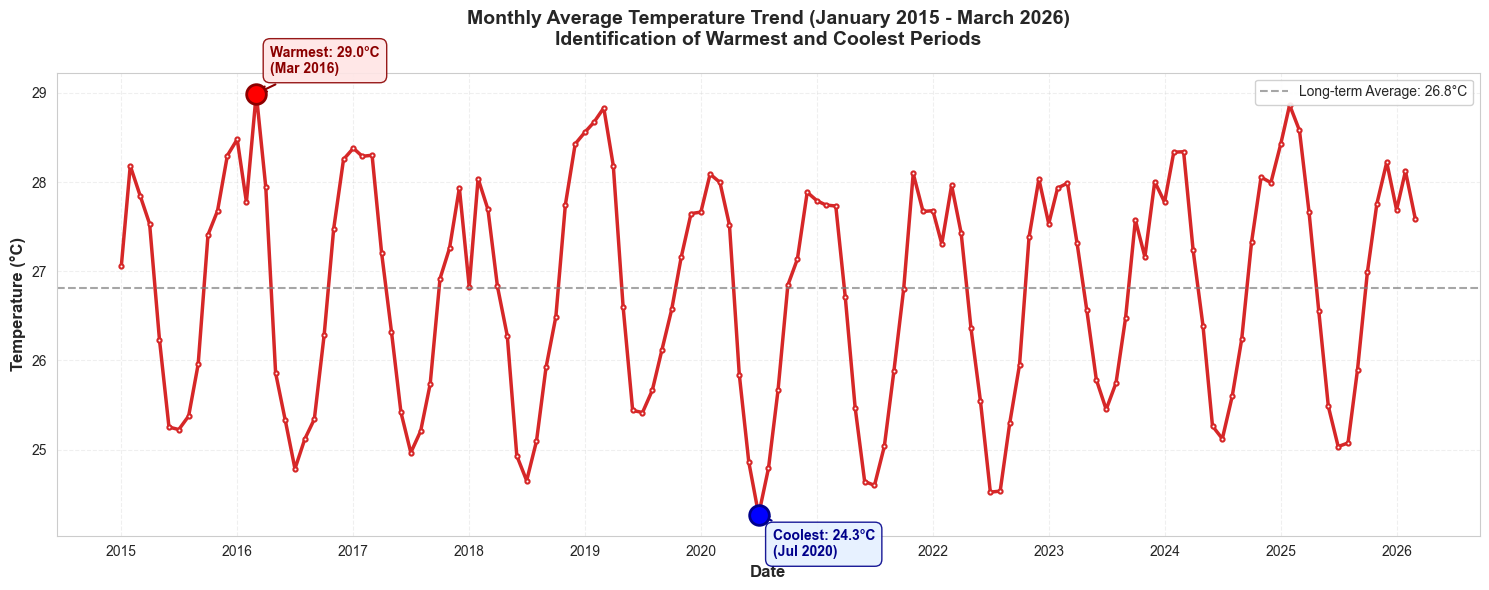

TEMPERATURE EXTREMES ANALYSIS
Data period: Jan 2015 - Mar 2026
★ Warmest Month: Mar 2016 - 29.0°C
★ Coolest Month: Jul 2020 - 24.3°C
📊 Temperature Range: 4.7°C
📈 Long-term Average: 26.8°C


In [15]:
# Prepare data
monthly_temp = df.resample("ME", on="Date")["T2M"].mean().reset_index()
monthly_temp['Month_Name'] = monthly_temp['Date'].dt.strftime('%b %Y')
monthly_temp['Year'] = monthly_temp['Date'].dt.year
monthly_temp['Month_Num'] = monthly_temp['Date'].dt.month

# Find warmest and coolest months
warmest_idx = monthly_temp['T2M'].idxmax()
coolest_idx = monthly_temp['T2M'].idxmin()
warmest_month = monthly_temp.loc[warmest_idx]
coolest_month = monthly_temp.loc[coolest_idx]

# Create the plot with cleaner line
plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")

# plot
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], 
         color='#d62728', linewidth=2.5, marker='o', 
         markersize=3, markerfacecolor='white', markeredgewidth=1.5,
         linestyle='-')

# Annotate warmest month
plt.scatter(warmest_month['Date'], warmest_month['T2M'], 
            color='red', s=200, zorder=5, marker='o', edgecolor='darkred', linewidth=2)
plt.annotate(f'Warmest: {warmest_month["T2M"]:.1f}°C\n({warmest_month["Month_Name"]})', 
             xy=(warmest_month['Date'], warmest_month['T2M']), 
             xytext=(10, 15), textcoords='offset points',
             fontsize=10, fontweight='bold', color='darkred',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffe5e5', edgecolor='darkred', alpha=0.9),
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

# Annotate coolest month
plt.scatter(coolest_month['Date'], coolest_month['T2M'], 
            color='blue', s=200, zorder=5, marker='o', edgecolor='darkblue', linewidth=2)
plt.annotate(f'Coolest: {coolest_month["T2M"]:.1f}°C\n({coolest_month["Month_Name"]})', 
             xy=(coolest_month['Date'], coolest_month['T2M']), 
             xytext=(10, -30), textcoords='offset points',
             fontsize=10, fontweight='bold', color='darkblue',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#e5f0ff', edgecolor='darkblue', alpha=0.9),
             arrowprops=dict(arrowstyle='->', color='darkblue', lw=1.5))

# Add horizontal line for average temperature
avg_temp = monthly_temp['T2M'].mean()
plt.axhline(y=avg_temp, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, 
            label=f'Long-term Average: {avg_temp:.1f}°C')

# Customize the chart
plt.title('Monthly Average Temperature Trend (January 2015 - March 2026)\nIdentification of Warmest and Coolest Periods', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='semibold')
plt.ylabel('Temperature (°C)', fontsize=12, fontweight='semibold')
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')

# Improve x-axis labels - show every 12 months (yearly)
ax = plt.gca()
years = pd.date_range(start='2015-01-31', end='2026-03-31', freq='12ME')
ax.set_xticks(years)
ax.set_xticklabels([yr.strftime('%Y') for yr in years], rotation=0)

plt.tight_layout()
plt.show()

# Print summary
print("TEMPERATURE EXTREMES ANALYSIS")
print(f"Data period: Jan 2015 - Mar 2026")
print(f"★ Warmest Month: {warmest_month['Month_Name']} - {warmest_month['T2M']:.1f}°C")
print(f"★ Coolest Month: {coolest_month['Month_Name']} - {coolest_month['T2M']:.1f}°C")
print(f"📊 Temperature Range: {warmest_month['T2M'] - coolest_month['T2M']:.1f}°C")
print(f"📈 Long-term Average: {avg_temp:.1f}°C")

### Monthly average `T2M` line chart (2015–2026) + warmest/coolest annotations
This is the *monthly mean temperature* trend across the full period. It’s mostly seasonal (repeating pattern each year), with smaller year-to-year variations.

**Key annotations (from the data)**
- **Warmest month:** **2016-03** with **~28.99 °C**
- **Coolest month:** **2020-07** with **~24.27 °C**

**Interpretation**
The fact that the warmest month lands in **March** and the coolest in **July** indicates a strong annual temperature cycle consistent with a location influenced by regional wet/dry seasonality and the solar cycle.

A practical way to read this chart is:
- The **peaks** (around the warmest months) represent periods with higher daily baseline heat.
- The **troughs** (cool season) represent periods when the whole temperature distribution shifts downward, not just a few cold days.

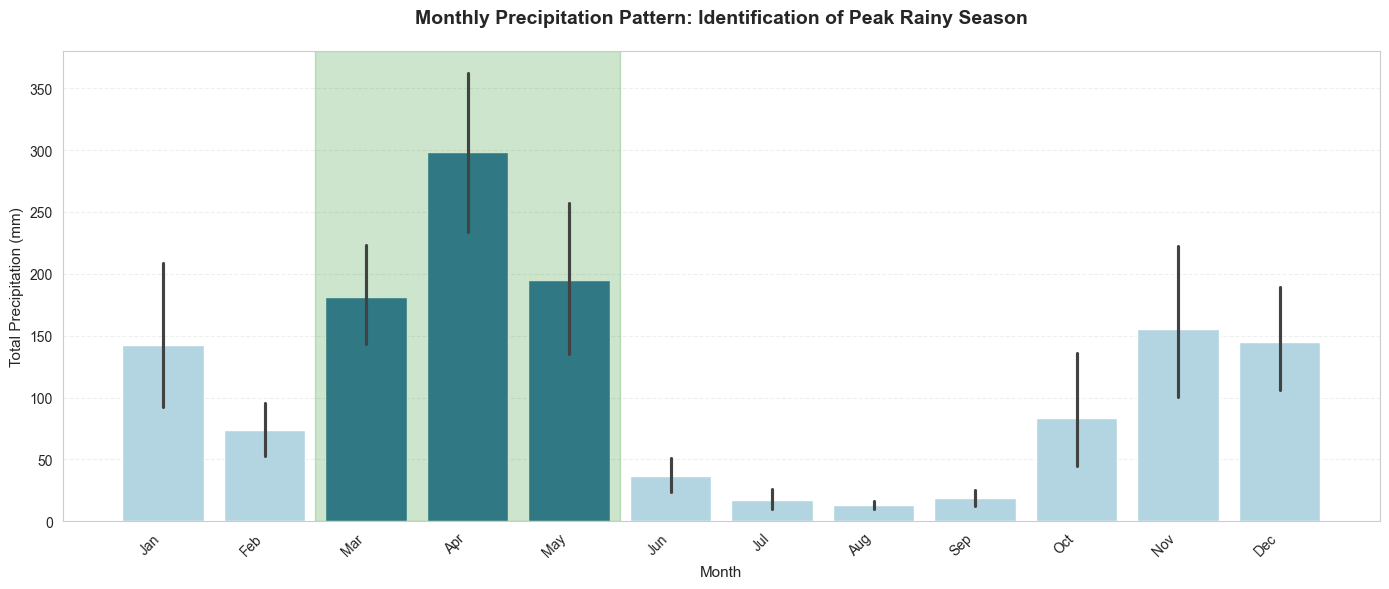


=== Peak Rainy Season Analysis ===
Peak months: 3-5
Total rain in peak season: 7599mm
Percentage of annual rain: 49.5%

=== Monthly Breakdown ===
Apr: 3279mm
Mar: 2173mm
May: 2147mm
Jan: 1712mm
Nov: 1709mm
Dec: 1598mm


In [16]:
# Prepare data
monthly_rain = df.resample("ME", on="Date")["PRECTOTCORR"].sum().reset_index()
monthly_rain['Month_Num'] = monthly_rain['Date'].dt.month
monthly_rain['Year'] = monthly_rain['Date'].dt.year
monthly_rain['Month_Name'] = monthly_rain['Date'].dt.strftime('%b')

# Calculate average by month across years
monthly_avg = df.groupby(df['Date'].dt.month)['PRECTOTCORR'].sum()

# --- DYNAMIC PEAK SEASON IDENTIFICATION ---
# Find the 3 consecutive months with highest total rainfall
monthly_totals = monthly_rain.groupby('Month_Num')['PRECTOTCORR'].sum()

best_total = 0
peak_start = 3  # default
peak_end = 5    # default

# Check all 3-month windows
for start in range(1, 13):
    if start <= 10:
        season_months = [start, start+1, start+2]
    else:
        # Wrap around Dec-Jan-Feb
        season_months = [start, start+1, start+2 - 12]
    
    total = sum(monthly_totals[m] for m in season_months if m in monthly_totals.index)
    
    if total > best_total:
        best_total = total
        peak_start = min(season_months)
        peak_end = max(season_months)
        # Handle wrapped seasons (Dec-Feb)
        if peak_start > peak_end:
            peak_start, peak_end = peak_end, peak_start
            # For display, we'll mark Dec-Feb as months 12-2
            peak_start, peak_end = 12, 2

# Create figure with professional styling
fig, ax = plt.subplots(figsize=(14, 6))

# Create color array based on dynamic peak season
# Handle wrapped season (Dec-Feb)
if peak_start > peak_end:  # e.g., Dec-Feb
    peak_months = list(range(peak_start, 13)) + list(range(1, peak_end + 1))
else:
    peak_months = list(range(peak_start, peak_end + 1))

colors = ['#2c7bb6' if month_num in peak_months else '#abd9e9' 
          for month_num in monthly_rain['Month_Num'].unique()]

# Bar plot
bars = sns.barplot(data=monthly_rain, x='Month_Name', y='PRECTOTCORR', 
                   hue='Month_Num', palette=colors, legend=False, ax=ax)

# Annotate highest peak
max_idx = monthly_rain['PRECTOTCORR'].idxmax()
max_value = monthly_rain.loc[max_idx, 'PRECTOTCORR']
max_month = monthly_rain.loc[max_idx, 'Month_Name']

ax.annotate(f'Highest: {max_value:.0f}mm', 
            xy=(max_idx, max_value), xytext=(max_idx, max_value + 30),
            ha='center', fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Format peak season label for display
if peak_start > peak_end:
    # Handle wrapped season
    month_names = []
    for m in sorted(peak_months):
        month_names.append(monthly_rain[monthly_rain['Month_Num'] == m]['Month_Name'].iloc[0])
    season_label = f'Peak Rainy Season ({", ".join(month_names)})'
    

    dec_indices = monthly_rain[monthly_rain['Month_Num'] == 12].index
    jan_feb_indices = monthly_rain[monthly_rain['Month_Num'].isin([1, 2])].index
    
    if len(dec_indices) > 0:
        ax.axvspan(dec_indices[0] - 0.5, dec_indices[-1] + 0.5, alpha=0.2, color='green')
    if len(jan_feb_indices) > 0:
        ax.axvspan(jan_feb_indices[0] - 0.5, jan_feb_indices[-1] + 0.5, alpha=0.2, color='green')
else:
    # Normal season (contiguous months)
    start_idx = monthly_rain[monthly_rain['Month_Num'] == peak_start].index[0]
    end_idx = monthly_rain[monthly_rain['Month_Num'] == peak_end].index[0]
    season_label = f'Peak Rainy Season (Month {peak_start}-{peak_end})'
    ax.axvspan(start_idx - 0.5, end_idx + 0.5, alpha=0.2, color='green', label=season_label)

# Add legend for shaded area if not already added
handles, labels = ax.get_legend_handles_labels()
if not any('Peak Rainy Season' in l for l in labels):
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='green', alpha=0.2, label=season_label)], 
              loc='upper right', framealpha=0.9)

# Styling
ax.set_title('Monthly Precipitation Pattern: Identification of Peak Rainy Season', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Precipitation (mm)', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Rotate x-labels
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print summary
print("\n=== Peak Rainy Season Analysis ===")
print(f"Peak months: {peak_start}-{peak_end}" if peak_start <= peak_end else f"Peak months: {peak_start}, {peak_end} (wrapped)")
print(f"Total rain in peak season: {best_total:.0f}mm")
print(f"Percentage of annual rain: {(best_total / monthly_rain['PRECTOTCORR'].sum() * 100):.1f}%")

# Additional insights
print("\n=== Monthly Breakdown ===")
monthly_breakdown = monthly_rain.groupby('Month_Num')['PRECTOTCORR'].sum().sort_values(ascending=False)
for month_num, total in monthly_breakdown.head(6).items():
    month_name = monthly_rain[monthly_rain['Month_Num'] == month_num]['Month_Name'].iloc[0]
    print(f"{month_name}: {total:.0f}mm")

### Monthly total `PRECTOTCORR` bar chart + “peak rainy season” annotations

1) **Rainfall is “spiky” in time.** Unlike temperature (smooth), precipitation often concentrates into a few intense months.

2) The biggest peaks clustering in **April** suggests a major rainy season component around that time (in many parts of Tanzania this aligns with the “long rains” period). Your data strongly supports that “April is a high-risk heavy rainfall month,” at least for this representative location.

## 9. Correlation & Relationship Analysis

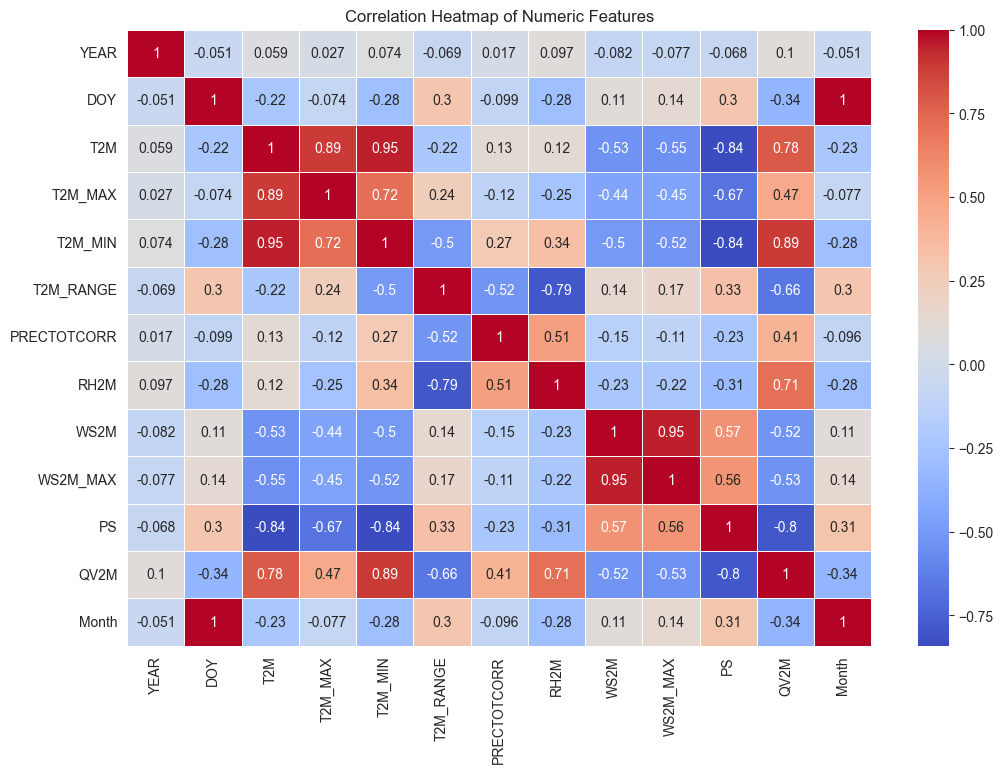

In [17]:
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

# plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # shows numbers inside cells
    cmap="coolwarm",   # color style
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [18]:
corr_pairs = corr_matrix.unstack()

# remove self-correlation (1.0)
corr_pairs = corr_pairs[corr_pairs != 1]

# sort by absolute strength
strongest = corr_pairs.abs().sort_values(ascending=False)

strongest.head(12)

DOY       Month       0.996557
Month     DOY         0.996557
WS2M      WS2M_MAX    0.951026
WS2M_MAX  WS2M        0.951026
T2M_MIN   T2M         0.950399
T2M       T2M_MIN     0.950399
          T2M_MAX     0.889655
T2M_MAX   T2M         0.889655
QV2M      T2M_MIN     0.888370
T2M_MIN   QV2M        0.888370
T2M       PS          0.840661
PS        T2M         0.840661
dtype: float64

### Correlation Analysis: Key Climate Variable Relationships

The strongest the linear correlations are:

1) **Day of Year and Month: r ≈0.997**

   This is **perfectly expected** and simply confirms that DOY and month are mathematically locked together. This is a validation of the data, not a climate finding.
   
2) **`WS2M` vs `WS2M_MAX`: r ≈ 0.951**  
Interpretation: days with higher mean wind speed also tend to have higher max gusts. This is physically intuitive—strong wind regimes elevate both the mean and the extremes.

3) **`T2M` vs `T2M_MIN`: r ≈ 0.950**  
Interpretation: in this climate, warmer days are strongly associated with warmer nights. This often happens when the main temperature driver is a broad-scale air mass / seasonal baseline rather than isolated daytime-only heating.

4) **`T2M` vs `T2M_MAX`: r ≈ 0.890**  
Interpretation: warmer average days also have warmer daytime highs. The fact this is slightly weaker than `T2M` vs `T2M_MIN` can happen when cloud/rain/humidity suppress daytime highs more variably than nighttime lows.

### T2M vs RH2M Scatter Plot

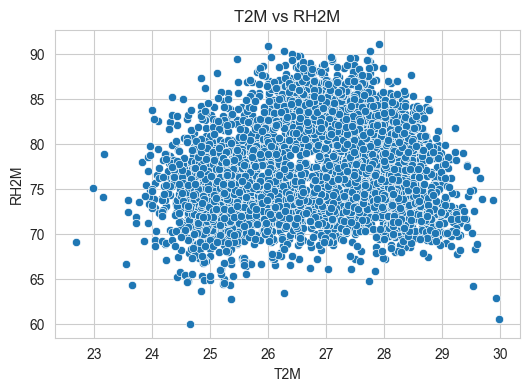

In [19]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("T2M vs RH2M")
plt.show()

### Scatter plot: `T2M` vs `RH2M`

It has a broad cloud shape rather than a tight line, which means:
- There isn’t one simple linear relationship dominating every day. There’s a **slight negative correlation**
- Multiple regimes likely exist: hot-humid rainy days, hot-drier days, cooler-humid days, etc.

So: **RH2M is not just a function of temperature**; it’s heavily influenced by rainfall events, cloud cover, and air mass changes.

### T2M_RANGE vs WS2M

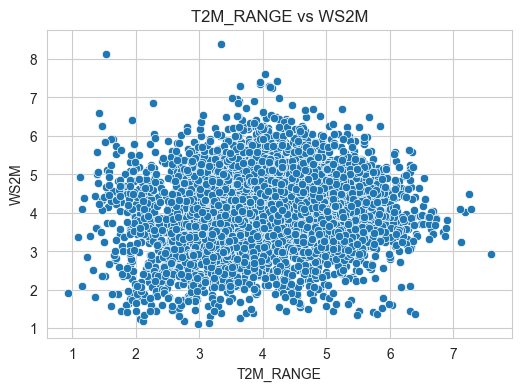

In [20]:
### Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.title("T2M_RANGE vs WS2M")
plt.show()

### Scatter: **`T2M_RANGE` vs `WS2M`**

**1) Overall shape**

* The point cloud is again **oval to dome-shaped**.
* There’s a **clear bulge in the middle** (around T2M_RANGE ≈ 3–5), giving it a slightly **elliptical / mound-like form**.

**2) Relationship / correlation**

* **no strong linear relationship**.
* There’s a **slight negative correlation**: as T2M_RANGE increases beyond ~4–5, WS2M tends to decrease a bit.
* At lower T2M_RANGE (≈2–4), you see **higher and more variable wind speeds**, including most of the high outliers (~7–8).
* Overall: **weak negative correlation**, but not strong enough to be predictive.

**3) Variability pattern**

* **Mid-range T2M_RANGE (≈3–5):**

  * Highest density of points.
  * Broad WS2M spread (~2–6+), indicating mixed wind conditions.
* **Higher T2M_RANGE (>5.5–6):**

  * WS2M becomes more constrained (~3–5).
  * Fewer extreme wind values.
* **Lower T2M_RANGE (<2.5):**

  * Still fairly spread out, with some high-wind outliers.

**4) Outliers**

* A handful of **high WS2M values (~7–8+)**, mostly at lower to mid T2M_RANGE.
* A few **low WS2M (~1–1.5)** scattered throughout.

## 10. Distribution Analysis

In [21]:
# Calculate skewness
precip_skew = skew(df['PRECTOTCORR'])
print(f"Skewness coefficient: {precip_skew:.2f}")

Skewness coefficient: 5.25


- Since the data is highly skewed we'll use log for the Histogram.

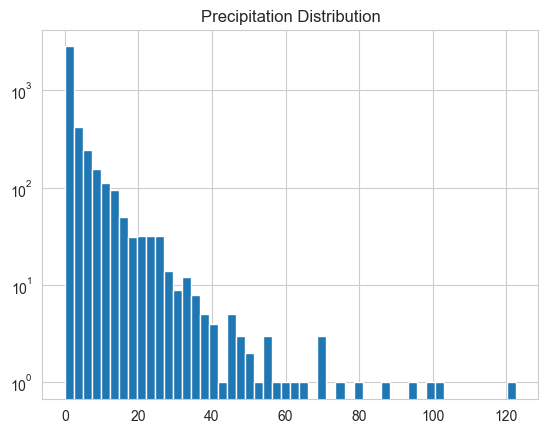

In [22]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=50)
plt.yscale("log") 
plt.title("Precipitation Distribution")
plt.show()

### Histogram of `PRECTOTCORR` with log scaling

**Interpretation (shape)**
This is a classic **right-skewed** precipitation distribution:
- Most days are low rain to light rain.
- A smaller number of days produce very large totals (the “tail”), which dominate monthly sums and flood risk.

The log transform compresses those extreme values so we can actually see the structure of the “typical” rainy days, not just the extremes.

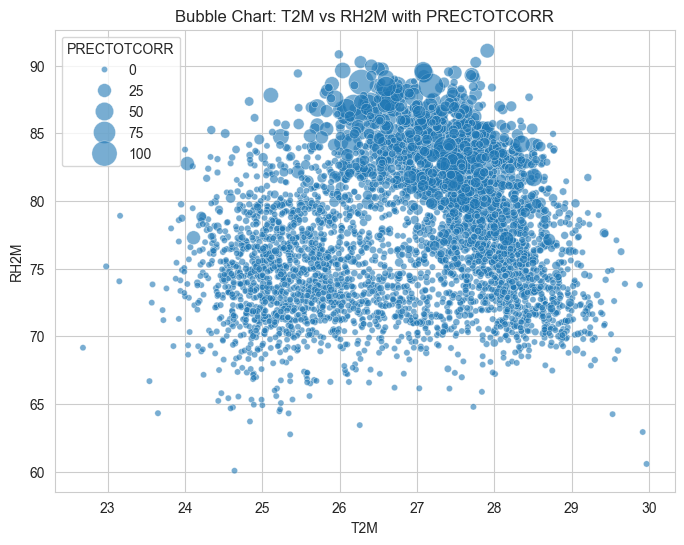

In [23]:
## bubble chart
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    size="PRECTOTCORR",
    sizes=(20, 400),
    alpha=0.6,
    legend=True
)

plt.title("Bubble Chart: T2M vs RH2M with PRECTOTCORR")
plt.show()

### Bubble chart: **T2M vs RH2M**, bubble size = **PRECTOTCORR**

**1) Overall shape (T2M vs RH2M)**

* The cloud forms a **broad, slightly curved/arched band** rather than a simple oval.
* Most points lie between **RH2M ~70–90%** and **T2M ~25–29°C**.
* There’s a noticeable **upper cluster (RH ~82–88)** and a **lower spread (RH ~70–75)**, giving it a somewhat **layered look**.

**2) Relationship between T2M and RH2M**

* The relationship looks **weakly nonlinear** rather than linear.
* Around **T2M ≈ 26–27**, RH2M tends to peak higher (more points in the 80–88 range).
* At **higher temperatures (≈28–30)**, RH2M tends to **drop slightly** (more points around 70–80).
* So overall: **very weak negative tendency at higher temperatures**, but not strong.

**3) Precipitation signal (bubble size: PRECTOTCORR)**
This is where the key insight is:

* **Largest bubbles (highest precipitation)** cluster around:

  * **RH2M ≈ 80–88%**
  * **T2M ≈ 26–28°C**
* **Very few large bubbles** appear at:

  * Low RH (<70%)
  * Very high T2M (>29°C)

This suggests:

* **High humidity is the main driver of precipitation**, much more than temperature alone.
* There’s a **“sweet spot” temperature range** (mid-to-high 20s °C) where precipitation is most likely when humidity is high.

**4) Variability patterns**

* **RH2M spread is wide at most temperatures**, meaning temperature alone doesn’t tightly control humidity.
* **Precipitation is highly selective**:

  * It doesn’t occur uniformly across the cloud.
  * It’s concentrated in a **specific humidity band**, not across all conditions.

**5) Outliers**

* A few **low-RH (~60–65%) points** with almost no precipitation (tiny bubbles).
* Some **high-RH (~90%+) points**, but not all of them have large precipitation—so **high RH is necessary but not sufficient**.

**6) Climate interpretation**

* This pattern is typical of **convective or tropical/subtropical regimes**:

  * Warm temperatures provide energy,
  * But **precipitation really “switches on” when humidity crosses a threshold**.
* The clustering of large bubbles suggests a **nonlinear precipitation response**:

  * Below ~75–78% RH → little rain
  * Above ~80% RH → rain becomes much more likely/intense
* The slight drop in RH at higher T2M could reflect **drying during hotter conditions** (or different air masses).
